# Bank‑Grade Credit Scoring PipelineThis notebook implements a **production‑style credit scoring workflow** used in banks and fintech credit risk systems.Pipeline includes:1. Data loading2. Exploratory analysis3. Train‑test split4. Handling class imbalance using SMOTE5. Models   - Logistic Regression   - XGBoost   - LightGBM6. Evaluation metrics   - AUC   - KS Statistic   - Gini7. PD Calibration8. SHAP Explainability9. Scorecard GenerationThis notebook can be run in **Google Colab or Jupyter**.

In [2]:
!pip install shap xgboost lightgbm imbalanced-learn

## 1 Import Libraries

In [3]:
import platform, struct, sys
print("python:", sys.version)
print("executable:", sys.executable)
print("machine:", platform.machine())
print("bits:", struct.calcsize("P") * 8)

python: 3.14.3 (main, Feb  3 2026, 15:32:20) [Clang 17.0.0 (clang-1700.6.3.2)]
executable: /Users/mruksad/Documents/IIT-B/epgd/thirdSem/AI-Ml_in_practice/local/bin/python
machine: arm64
bits: 64


In [4]:
import traceback
try:
    import xgboost
except Exception as e:
    print("Import failed:", repr(e))
    traceback.print_exc()

In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.calibration import calibration_curve
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from imblearn.over_sampling import SMOTE
import xgboost as xgb
import lightgbm as lgb
import shap
import matplotlib.pyplot as plt

/Users/mruksad/Documents/IIT-B/epgd/thirdSem/AI-Ml_in_practice/local/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2 Generate Example Credit Dataset

In [7]:
np.random.seed(42)
n=6000
data = pd.DataFrame({"age": np.random.randint(21,70,n),
                     "income": np.random.normal(50000,15000,n),
                     "loan_amount": np.random.normal(15000,5000,n),
                     "credit_utilization": np.random.uniform(0,1,n),
                     "num_delinquency": np.random.poisson(0.3,n)})
data["default"] = ((data.credit_utilization>0.75)|(data.loan_amount/data.income>0.65)|(data.num_delinquency>1)).astype(int)
data.head()

,age,income,loan_amount,credit_utilization,num_delinquency,default
0,59,49412.414441,11877.620786,0.926043,1,1
1,49,49061.673710,20897.063065,0.503218,0,0
2,35,33821.943912,11770.721001,0.347735,2,1
3,63,36575.939697,8951.336469,0.971572,0,1
4,28,35401.523370,18337.716557,0.425782,0,0




**1) Normal (Gaussian) distribution**
- **What it models:** A continuous variable that clusters around a mean with symmetric “bell-shaped” noise (many small independent effects add up).
- **Parameters:** mean $\mu$ and standard deviation $\sigma$.
- **Notation:** $X \sim \mathcal{N}(\mu,\sigma^2)$
- **Key properties**
  - Symmetric around $\mu$; mean = median = mode = $\mu$
  - About **68%** of values lie in $[\mu-\sigma,\mu+\sigma]$, **95%** in $[\mu-2\sigma,\mu+2\sigma]$
  - Support is theoretically $(-\infty,\infty)$ (so it can produce negative values unless clipped)

**Example (matches your notebook)**
- Income generated as `np.random.normal(50000, 15000, n)`
  - Here $\mu=50{,}000$ and $\sigma=15{,}000$.
  - Rough intuition:
    - ~68% of incomes fall between $35{,}000$ and $65{,}000$
    - ~95% between $20{,}000$ and $80{,}000$
- Loan amount generated similarly around $15{,}000$ with $\sigma=5{,}000$.

**When it’s appropriate**
- Measurement noise, aggregated quantities, many “small effects” variables.
- In finance, raw income often looks *skewed* (more like log-normal), but normal is a simple synthetic assumption.

---

**2) Uniform distribution**
- **What it models:** A continuous variable where **every value in an interval is equally likely** (no preference within the range).
- **Parameters:** lower bound $a$ and upper bound $b$.
- **Notation:** $X \sim \text{Uniform}(a,b)$
- **Key properties**
  - Flat density on $[a,b]$
  - Mean $= \frac{a+b}{2}$
  - Variance $= \frac{(b-a)^2}{12}$
  - Support is strictly bounded: it never generates values outside $[a,b]$

**Example (matches your notebook)**
- Credit utilization generated as `np.random.uniform(0, 1, n)`
  - Values are equally likely between 0% and 100%.
  - Mean is $\frac{0+1}{2}=0.5$.
- Real-world note: credit utilization is rarely uniform; it might cluster near low values for many borrowers, with a tail near 1. But uniform is handy when you just want coverage across the whole range.

**When it’s appropriate**
- Simulations where you want unbiased coverage over a range (e.g., random threshold tests, random initialization).
- When you truly believe “any value in the interval is equally likely” (less common in real data, more common in synthetic setups).

---

**3) Poisson distribution**
- **What it models:** A **count** of events in a fixed window (time/area/exposure) when events happen independently at an average rate.
  - Examples: number of late payments in a month, number of claims per year, number of calls per hour.
- **Parameter:** rate $\lambda$ (average count per window).
- **Notation:** $X \sim \text{Poisson}(\lambda)$
- **PMF (probability of exactly $k$ events):**
  $$
  P(X=k)=\frac{e^{-\lambda}\lambda^k}{k!},\quad k=0,1,2,\dots
  $$
- **Key properties**
  - Discrete: only non-negative integers
  - Mean $=\lambda$
  - Variance $=\lambda$ (important: variance tied to mean)

**Example (matches your notebook)**
- Delinquencies generated as `np.random.poisson(0.3, n)` so $\lambda=0.3$ (rare events).
  - Probabilities:
    - $P(X=0)=e^{-0.3}\approx 0.7408$ (about 74% have zero delinquencies)
    - $P(X=1)=e^{-0.3}\cdot 0.3\approx 0.2222$
    - $P(X=2)=e^{-0.3}\cdot 0.3^2/2\approx 0.0333$
    - $P(X\ge 2)\approx 1-0.7408-0.2222=0.037$ (about 3.7%)
- This aligns with credit behavior where most borrowers have 0 late payments, some have 1, few have 2+.

**When it’s appropriate**
- Event counts that are relatively rare and independent in a fixed exposure window.
- If the data shows “variance much larger than mean” (over-dispersion), a Negative Binomial model often fits better than Poisson.

---

**How these relate to your default rule**
In above example:
- `income ~ Normal`, `loan_amount ~ Normal` create continuous financial variables.
- `credit_utilization ~ Uniform(0,1)` creates a bounded ratio.
- `num_delinquency ~ Poisson(0.3)` creates a realistic “mostly zeros” count.
Then default is flagged by logical conditions like utilization > 0.75 or delinquencies > 1.

## 3 Train Test Split

In [8]:
X=data.drop("default",axis=1)
y=data["default"]
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.3,stratify=y,random_state=42)

## 4 Handle Class Imbalance with SMOTE

In [9]:
sm=SMOTE(random_state=42)
X_train_res,y_train_res=sm.fit_resample(X_train,y_train)
print("Before:",y_train.value_counts())
print("After:",pd.Series(y_train_res).value_counts())

Before: default
0    2859
1    1341
Name: count, dtype: int64
After: default
0    2859
1    2859
Name: count, dtype: int64


## 5 Preprocessing Pipeline

In [18]:
num_features=X.columns.tolist()
numeric_pipeline=Pipeline([("imputer",SimpleImputer(strategy="median")),("scaler",StandardScaler())])
preprocess=ColumnTransformer([("num",numeric_pipeline,num_features)])

## 6 Train Logistic Regression Model

In [11]:
log_model=Pipeline([("prep",preprocess),("model",LogisticRegression())])
log_model.fit(X_train_res,y_train_res)
prob_log=log_model.predict_proba(X_test)[:,1]
auc_log=roc_auc_score(y_test,prob_log)
print("Logistic AUC:",auc_log)

Logistic AUC: 0.9326736468500444


## 7 Train XGBoost Model

In [12]:
xgb_model=xgb.XGBClassifier(n_estimators=300,max_depth=4,learning_rate=0.05,subsample=0.8,colsample_bytree=0.8)
xgb_model.fit(X_train_res,y_train_res)
prob_xgb=xgb_model.predict_proba(X_test)[:,1]
auc_xgb=roc_auc_score(y_test,prob_xgb)
print("XGBoost AUC:",auc_xgb)

XGBoost AUC: 0.9999062999112689


## 8 Train LightGBM Model

In [13]:
lgb_model=lgb.LGBMClassifier(n_estimators=300,learning_rate=0.05,num_leaves=31)
lgb_model.fit(X_train_res,y_train_res)
prob_lgb=lgb_model.predict_proba(X_test)[:,1]
auc_lgb=roc_auc_score(y_test,prob_lgb)
print("LightGBM AUC:",auc_lgb)

[LightGBM] [Info] Number of positive: 2859, number of negative: 2859
[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.000368 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 820
[LightGBM] [Info] Number of data points in the train set: 5718, number of used features: 5
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.500000 -> initscore=0.000000
LightGBM AUC: 0.9987407275953861


## 9 KS Statistic

In [14]:
def ks_stat(y_true,prob):
    fpr,tpr,thr=roc_curve(y_true,prob)
    return max(tpr-fpr)

print("KS Logistic:",ks_stat(y_test,prob_log))
print("KS XGB:",ks_stat(y_test,prob_xgb))
print("KS LGB:",ks_stat(y_test,prob_lgb))

KS Logistic: 0.7320674356699202
KS XGB: 0.9917302573203195
KS LGB: 0.9862999112688553


### What this code is doing (preprocessing block)

The snippet:



In [19]:
num_features = X.columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer([
    ("num", numeric_pipeline, num_features)
])

In [20]:
log_model = Pipeline([("prep", preprocess), ("model", LogisticRegression())])
log_model.fit(X_train_res, y_train_res)
prob_log = log_model.predict_proba(X_test)[:, 1]
auc_log = roc_auc_score(y_test, prob_log)

### 1) Explain this code (Pipeline + preprocessing + Logistic Regression)

#### a) `num_features = X.columns.tolist()`
- Takes all column names from your feature matrix `X` and stores them in a Python list.
- Meaning: “these are the columns I want to treat as numeric features.”

#### b) `numeric_pipeline = Pipeline([...])`
This defines **two preprocessing steps** applied in order:

1) `SimpleImputer(strategy="median")`
- If any numeric values are missing (`NaN`), it fills them with the **median** of that column (median is computed from the training data during `fit`).

2) `StandardScaler()`
- Standardizes each numeric column so it has roughly mean 0 and standard deviation 1.
- Transformation:

$$
z = \frac{x - \mu}{\sigma}
$$

This is especially helpful for **Logistic Regression**, because scaling makes optimization more stable and coefficients more comparable.

#### c) `preprocess = ColumnTransformer([("num", numeric_pipeline, num_features)])`
- `ColumnTransformer` applies transformations to specific columns.
- Here: apply `numeric_pipeline` to the columns in `num_features`.
- This pattern is “production style” because later you can easily add another transformer for categorical columns (for example, one-hot encoding) without rewriting everything.

#### d) `log_model = Pipeline([("prep", preprocess), ("model", LogisticRegression())])`
- This makes one end-to-end pipeline:
  1) `prep`: imputes + scales
  2) `model`: trains logistic regression

#### e) `log_model.fit(X_train_res, y_train_res)`
- Fits the preprocessing using training data (learns medians, learns scaling parameters),
- then fits Logistic Regression on the transformed training data.

#### f) `prob_log = log_model.predict_proba(X_test)[:, 1]`
- Produces predicted probabilities for each class on the test set.
- `[:, 1]` picks the probability of the **positive class** (here `default = 1`), i.e., predicted probability of default (PD).

---

### 2) What is `roc_auc_score`?

`roc_auc_score(y_test, prob_log)` computes **AUC-ROC**:

- **ROC curve** is a plot of True Positive Rate (TPR) vs False Positive Rate (FPR) as you vary the classification threshold.

Definitions:

$$
\mathrm{TPR} = \frac{\mathrm{TP}}{\mathrm{TP} + \mathrm{FN}}
$$

$$
\mathrm{FPR} = \frac{\mathrm{FP}}{\mathrm{FP} + \mathrm{TN}}
$$

- **AUC** is the area under that ROC curve.
- Interpretation:
  - AUC = 0.5 means random ranking
  - AUC = 1.0 means perfect ranking

A very useful intuition (credit-scoring friendly):
- AUC is the probability that a randomly chosen defaulter gets a higher score than a randomly chosen non-defaulter.

**Important:** AUC expects a *score/probability* like `prob_log`, not hard labels.

`roc_auc_score` computes the **ROC AUC** (Area Under the Receiver Operating Characteristic curve). It evaluates how well your model **ranks** defaulters above non-defaulters across *all* possible probability thresholds.

---

## 1) What ROC curve is

Suppose you have:
- true labels $y \in \{0,1\}$ (0 = non-default, 1 = default)
- model scores $s$ (usually predicted probabilities of default)

For any threshold $t$, predict default if $s >= t$. This produces a confusion matrix with:
- $\mathrm{TP}$, $\mathrm{FP}$, $\mathrm{TN}$, $\mathrm{FN}$

Define:

$$
\mathrm{TPR}(t) = \frac{\mathrm{TP}(t)}{\mathrm{TP}(t) + \mathrm{FN}(t)}
$$

$$
\mathrm{FPR}(t) = \frac{\mathrm{FP}(t)}{\mathrm{FP}(t) + \mathrm{TN}(t)}
$$

The **ROC curve** is the set of points $(\mathrm{FPR}(t), \mathrm{TPR}(t))$ as you vary $t$ from very high (almost nobody predicted default) to very low (almost everybody predicted default).

---

## 2) What AUC means

**AUC** is the area under that ROC curve, a number between 0 and 1.

Key interpretation (most important in credit scoring):

$$
\mathrm{AUC} = P(s^+ > s^-)
$$

That is, AUC is the probability that a randomly chosen positive example (a defaulter) gets a higher score than a randomly chosen negative example (a non-defaulter). (Ties count as half in the standard definition.)

Rules of thumb:
- AUC = 0.5: random ranking
- AUC = 1.0: perfect ranking
- AUC < 0.5: ranking is “reversed” (often means you swapped labels or used $P(y=0)$ instead of $P(y=1)$)

---

## 3) Example 1 (manual AUC using the ranking definition)

Let:

- $y = [0, 0, 1, 1]$
- $s = [0.10, 0.40, 0.35, 0.80]$

Positives (where $y=1$): scores $s^+ = [0.35, 0.80]$  
Negatives (where $y=0$): scores $s^- = [0.10, 0.40]$

Compare each positive to each negative (2 x 2 = 4 comparisons):
- 0.35 vs 0.10: win
- 0.35 vs 0.40: loss
- 0.80 vs 0.10: win
- 0.80 vs 0.40: win

Wins = 3 out of 4, so:

$$
\mathrm{AUC} = \frac{3}{4} = 0.75
$$

This tells you: the model ranks a defaulter above a non-defaulter 75% of the time.

---

## 4) Example 2 (build ROC points by changing thresholds)

Using the same $y$ and $s$, evaluate a few thresholds $t$:

- If $t > 0.80$: nobody predicted default  
  TPR = 0, FPR = 0
- If $t = 0.80$: only score 0.80 predicted default (a true positive)  
  TPR = 1/2, FPR = 0/2
- If $t = 0.40$: scores 0.80 and 0.40 predicted default (one TP and one FP)  
  TPR = 1/2, FPR = 1/2
- If $t = 0.35$: scores 0.80, 0.40, 0.35 predicted default (two TP and one FP)  
  TPR = 2/2, FPR = 1/2
- If $t <= 0.10$: everybody predicted default  
  TPR = 2/2, FPR = 2/2

Plot these (FPR on x-axis, TPR on y-axis) and compute the area under the curve; you get AUC = 0.75.

---

## 5) How to use `roc_auc_score` correctly (common mistakes)

- Pass **probabilities/scores**, not hard class labels:
  - correct: `roc_auc_score(y_test, model.predict_proba(X_test)[:, 1])`
  - incorrect: `roc_auc_score(y_test, model.predict(X_test))` (this collapses to a single threshold and loses the ROC idea)

- Make sure your scores correspond to the positive class ($y=1$). If you accidentally use the probability of class 0, your AUC can flip to $1 - \mathrm{AUC}$.

---

## 6) What AUC is good for (and what it is not)

Good for:
- measuring **ranking power** independent of a chosen cutoff
- comparing models when you care about ordering customers by risk

Not good for:
- calibration (whether 0.20 really means 20% default rate)
- choosing an operating threshold (you still need business constraints, KS, cost-based cutoff, etc.)

If you want, I can also show a small Python example using `roc_curve` to print thresholds and ROC points, and explain how AUC relates to Gini:

$$
\mathrm{Gini} = 2 \cdot \mathrm{AUC} - 1
$$

## 10 PD Calibration Curve

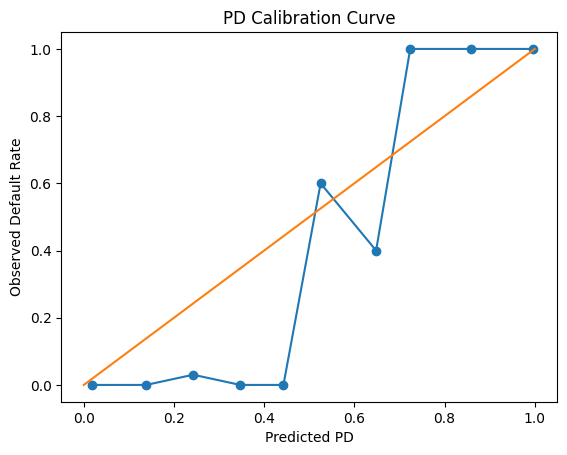

In [15]:
prob_true,prob_pred=calibration_curve(y_test,prob_xgb,n_bins=10)
plt.figure()
plt.plot(prob_pred,prob_true,marker="o")
plt.plot([0,1],[0,1])
plt.xlabel("Predicted PD")
plt.ylabel("Observed Default Rate")
plt.title("PD Calibration Curve")
plt.show()

## 11 SHAP Explainability

/var/folders/k6/d3j6nymn049fbg1pkkprxqtm0000gn/T/ipykernel_7592/1335666562.py:3: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(shap_values,X_test)


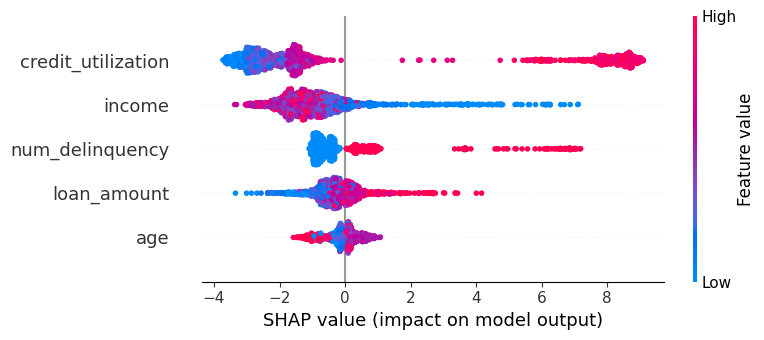

In [16]:
explainer=shap.TreeExplainer(xgb_model)
shap_values=explainer.shap_values(X_test)
shap.summary_plot(shap_values,X_test)

## 12 Feature Importance

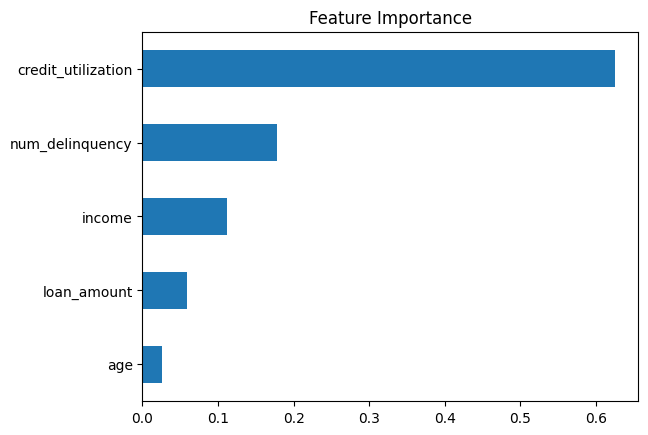

In [17]:
importance=pd.Series(xgb_model.feature_importances_,index=X.columns)
importance.sort_values().plot(kind="barh")
plt.title("Feature Importance")
plt.show()

## 13 Credit Scorecard Generation

In [30]:
# Convert PD to credit score
def pd_to_score(pd_prob):
    base_score = 600
    pdo = 50
    # Add a small epsilon to avoid division by zero or log(0)
    pd_prob = np.clip(pd_prob, 1e-6, 1 - 1e-6)
    odds = (1 - pd_prob) / pd_prob
    score = base_score + pdo * np.log(odds)
    return score

scores = pd.Series(prob_xgb).apply(pd_to_score)
scores.head()

,0
0,711.797977
1,709.307266
2,771.809448
3,697.071736
4,828.284934


## 14 Score DistributionHigher score = lower default risk

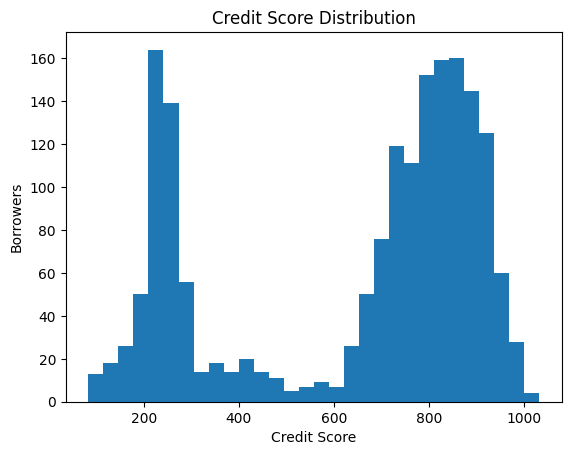

In [31]:
plt.hist(scores,bins=30)
plt.xlabel("Credit Score")
plt.ylabel("Borrowers")
plt.title("Credit Score Distribution")
plt.show()